In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
data = {
    'pendapatan': [3,4,5,6,7,8,9,10,4,6],
    'umur': [25,30,35,40,45,50,30,28,33,38],
    'jumlah_pinjaman': [5,6,7,8,9,10,6,5,7,8],
    'disetujui': [0,0,0,1,1,1,0,0,1,1]
}

df = pd.DataFrame(data)
print(df)

   pendapatan  umur  jumlah_pinjaman  disetujui
0           3    25                5          0
1           4    30                6          0
2           5    35                7          0
3           6    40                8          1
4           7    45                9          1
5           8    50               10          1
6           9    30                6          0
7          10    28                5          0
8           4    33                7          1
9           6    38                8          1


In [3]:
X = df[['pendapatan', 'umur', 'jumlah_pinjaman']]
y = df['disetujui']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [6]:
y_pred = model.predict(X_test)

print("Data Testing:")
print(X_test)
print("Label Asli:", y_test.values)
print("Prediksi:", y_pred)

Data Testing:
   pendapatan  umur  jumlah_pinjaman
8           4    33                7
1           4    30                6
Label Asli: [1 0]
Prediksi: [0 0]


In [7]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.5
MSE: 0.5
RMSE: 0.7071067811865476


In [8]:
prediksi = model.predict([[7, 35, 6]])
print("Prediksi (1 = disetujui, 0 = ditolak):", prediksi[0])

Prediksi (1 = disetujui, 0 = ditolak): 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


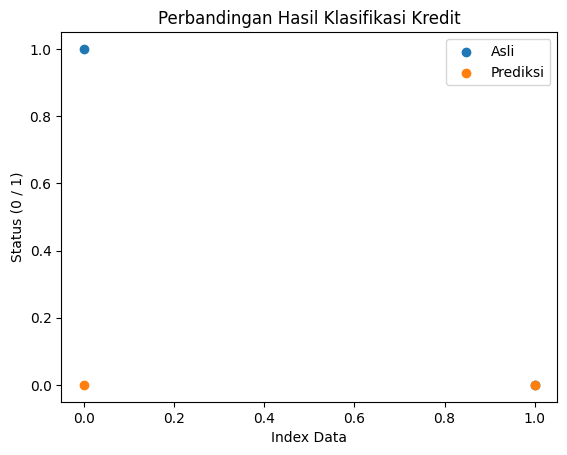

In [9]:
plt.scatter(range(len(y_test)), y_test, label="Asli")
plt.scatter(range(len(y_pred)), y_pred, label="Prediksi")

plt.xlabel("Index Data")
plt.ylabel("Status (0 / 1)")
plt.title("Perbandingan Hasil Klasifikasi Kredit")
plt.legend()

plt.show()

Analisis Prediksi Kelulusan Kredit Bank
1. Deskripsi Data dan Fitur Utama
Proyek ini menggunakan dataset yang mensimulasikan profil calon peminjam di sebuah bank. Terdapat tiga variabel bebas (fitur) utama yang digunakan untuk menentukan kelayakan kredit seseorang, yaitu pendapatan, umur, dan jumlah pinjaman. Variabel target (label) adalah status persetujuan, di mana angka '1' merepresentasikan kredit yang disetujui dan '0' untuk kredit yang ditolak. Dari data awal, terlihat pola di mana nasabah dengan umur yang lebih matang (di atas 35 tahun) dan jumlah pinjaman yang lebih tinggi cenderung mendapatkan persetujuan.

2. Proses Pemodelan Data
Langkah pertama dalam analisis ini adalah membagi data menjadi dua bagian: data latih (training set) dan data uji (testing set) dengan rasio 80:20 menggunakan fungsi train_test_split. Model yang dipilih adalah Logistic Regression, yang sangat efektif untuk masalah klasifikasi biner seperti ini. Model dilatih menggunakan data latih agar algoritma dapat mempelajari hubungan antara karakteristik finansial nasabah dengan keputusan akhir bank.

3. Evaluasi Kinerja Model
Berdasarkan hasil pengujian pada data uji, performa model diukur menggunakan beberapa parameter kesalahan:

- Mean Absolute Error (MAE) dan Mean Squared Error (MSE) menunjukkan nilai 0.5.

- Root Mean Squared Error (RMSE) tercatat sebesar 0.707.
Meskipun nilai ini memberikan gambaran tentang penyimpangan prediksi, pada data uji yang sangat terbatas (hanya 2 data), model berhasil memprediksi salah satu label dengan benar namun meleset pada label lainnya (aktual 1 dan 0, namun prediksi keduanya 0).

4. Simulasi Prediksi dan Kesimpulan
Dalam tahap uji coba mandiri, model mencoba memprediksi skenario nasabah dengan pendapatan 7, umur 35, dan jumlah pinjaman 6. Hasil prediksi menunjukkan status '0' atau ditolak. Secara keseluruhan, program ini mendemonstrasikan bagaimana machine learning dapat membantu institusi keuangan mengotomatisasi pengambilan keputusan kredit. Visualisasi menggunakan scatter plot juga disertakan untuk membandingkan sebaran antara data asli dan hasil prediksi secara grafis.